In [21]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from scipy.stats import loguniform
from sklearn.metrics import f1_score, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import lightgbm as lgb
from lightgbm import LGBMClassifier
import joblib

In [5]:
def get_data_path(relative_path: str = "") -> Path:
    """Retorna la ruta absoluta a la carpeta de datos compartida."""
    # Busca la raíz del repositorio basándose en este archivo (src/config.py)
    root = Path.cwd().parent.parent
    data_dir = root / relative_path
    
    if not data_dir.exists():
        os.makedirs(data_dir)
        
    return data_dir

In [9]:
data_dir = get_data_path("data/data-09-2025")
super_data = pd.read_excel(data_dir / 'DETERIORO-SUPERSOLIDARIA_2025-09.xlsx',
                           sheet_name='Datos')
super_calif = pd.read_excel(data_dir / 'DETERIORO-SUPERSOLIDARIA_2025-09.xlsx',
                            sheet_name='Calificación')
super_total = pd.merge(super_data, super_calif, on='N.Credito')
super_total.head()

,N.Credito,TipoId,NIT,Nombres,Apellido,Activo,Cod.Contable,Cartera_x,Fec.Ingreso,Fec.Desembolso,...,NODO4,Z,Puntaje,Calif.altura,Calif.modelo,Calif.evCartera,Calif.reestr,Calif.arrastre,Calif.final,Calif.homologada
0,002-002-0118009-5,C,42791041,Adriana Maria,Correa,1,144105,Consumo con libranza,2002-07-24,2020-09-04,...,0.0,-4.179,0.015083,NaN,A,NaN,NaN,A,A,A
1,002-002-0122632-2,C,42791041,Adriana Maria,Correa,1,144105,Consumo con libranza,2002-07-24,2021-07-21,...,0.0,-4.179,0.015083,NaN,A,NaN,NaN,A,A,A
2,002-002-0176644-4,C,42791041,Adriana Maria,Correa,1,144205,Consumo sin libranza,2002-07-24,2025-05-06,...,0.0,-3.725,0.023545,NaN,A,NaN,NaN,A,A,A
3,002-002-0174537-9,C,42791041,Adriana Maria,Correa,1,144205,Consumo sin libranza,2002-07-24,2024-12-30,...,0.0,-3.725,0.023545,NaN,A,NaN,NaN,A,A,A
4,007-002-0000017-5,C,42791041,Adriana Maria,Correa,1,144205,Consumo sin libranza,2002-07-24,2021-07-30,...,0.0,-3.375,0.033086,NaN,A,NaN,NaN,A,A,A


# Con libranza

In [11]:
super_total_con_libranza = super_total[super_total['Cartera_x'] == 'Consumo con libranza']
con_libranza_columns = ['Activo', 'Aportes', 'TipoCuota', 'AhorroCDAT', 'MoraMax03', 'MoraMax12', 'MoraMax24', 'Z', 'SINMORA', 
                        'Vinculacion', 'Calif.modelo','Calif.arrastre','Calif.final', 'Calif.homologada']
super_total_con_libranza = super_total_con_libranza[con_libranza_columns].copy()
# Gestión de datos nulos
super_total_con_libranza['AhorroCDAT']= super_total_con_libranza['AhorroCDAT'].fillna(0)
super_total_con_libranza.dropna(subset=['Z'], inplace=True)
# Eliminar columnas innecesarias
super_total_con_libranza.drop(columns=['TipoCuota'], inplace=True)
# Eliminar sujetos con "Activo" = 0
super_total_con_libranza = super_total_con_libranza[super_total_con_libranza['Activo'] != 0]
super_total_con_libranza.rename(mapper={'Aportes': 'AP', 'Vinculacion': 'ANTI', 'AhorroCDAT': 'COOCDAT', 'MoraMax12':'MORA12', 'MoraMax03':'MORA03', 'MoraMax24':'MORA24'}, axis=1, inplace=True)
super_total_con_libranza.head()

,Activo,AP,COOCDAT,MORA03,MORA12,MORA24,Z,SINMORA,ANTI,Calif.modelo,Calif.arrastre,Calif.final,Calif.homologada
0,1,8617980,0.0,0,0,0,-4.179,1.0,8469,A,A,A,A
1,1,2625443,0.0,0,0,0,-4.179,1.0,8469,A,A,A,A
17,1,39146709,0.0,0,0,0,-4.179,1.0,12363,A,A,A,A
26,1,11406354,0.0,0,79,79,-0.542,0.0,10477,D,D,D,C
27,1,19131147,0.0,0,0,0,-4.179,1.0,10477,A,D,D,A


In [13]:
for col in super_total_con_libranza.select_dtypes(include=['str']).columns:
    print("--------------------")
    print(super_total_con_libranza[col].value_counts())

--------------------
Calif.modelo
A    7234
B     103
D      36
Name: count, dtype: int64
--------------------
Calif.arrastre
A    7149
B     156
D      47
C      21
Name: count, dtype: int64
--------------------
Calif.final
A    7149
B     156
D      47
C      21
Name: count, dtype: int64
--------------------
Calif.homologada
A    7291
B      46
C      36
Name: count, dtype: int64


In [14]:
super_total_con_libranza['Calif.final'].value_counts()/len(super_total_con_libranza)

Calif.final
A    0.969619
B    0.021158
D    0.006375
C    0.002848
Name: count, dtype: float64

In [15]:
super_total_con_libranza['Z'].value_counts().sort_index()

Z
-4.179    7203
-3.604      17
-3.285      14
-1.109     103
-0.542      36
Name: count, dtype: int64

## Modelado

In [16]:
vars = ['AP', 'COOCDAT', 'MORA12', 'SINMORA', 'ANTI']

X = super_total_con_libranza[vars]

y = super_total_con_libranza['Calif.modelo']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21, stratify=y)

### Decision tree

In [17]:
le = LabelEncoder()
y_train_le = le.fit_transform(y_train)
y_test_le = le.transform(y_test)

dist = {'ccp_alpha':loguniform(1e-3, 1e2)}

grid_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=21, class_weight='balanced'), 
    param_distributions=dist, 
    scoring='f1_macro',
    n_iter=20,
    random_state=21,
    )
    
grid_search.fit(X_train, y_train_le)

train_score = f1_score(y_train_le, grid_search.predict(X_train), average='macro')
test_score = f1_score(y_test_le, grid_search.predict(X_test), average='macro')

print(f'Best score: {grid_search.best_score_:.2f} with {grid_search.best_params_}')
print(f'Train score: {train_score:.2f}')
print(f'Test score: {test_score:.2f}')

Best score: 1.00 with {'ccp_alpha': np.float64(0.0017523643286618828)}
Train score: 1.00
Test score: 0.97


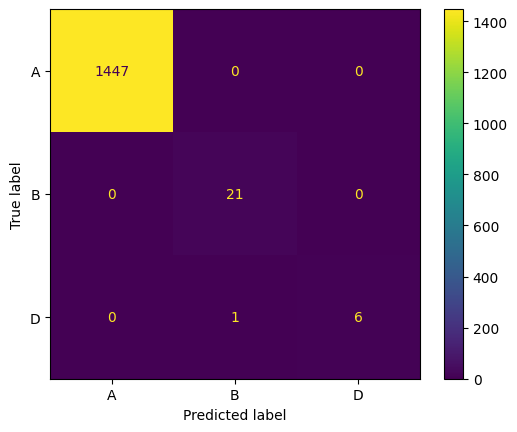

In [18]:
ConfusionMatrixDisplay.from_estimator(grid_search.best_estimator_, X_test, y_test_le, display_labels=le.classes_);

In [19]:
print(classification_report(y_test_le, grid_search.best_estimator_.predict(X_test), target_names=le.classes_))

              precision    recall  f1-score   support

           A       1.00      1.00      1.00      1447
           B       0.95      1.00      0.98        21
           D       1.00      0.86      0.92         7

    accuracy                           1.00      1475
   macro avg       0.98      0.95      0.97      1475
weighted avg       1.00      1.00      1.00      1475



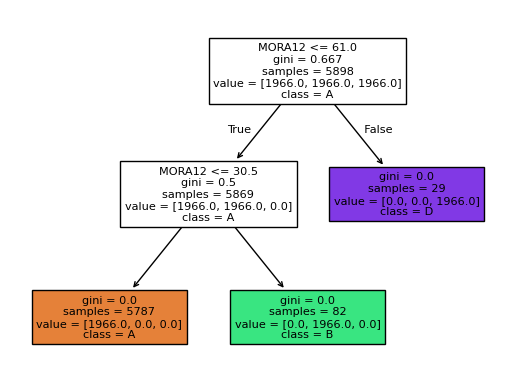

In [20]:
plt.figure()
plot_tree(grid_search.best_estimator_, filled=True, feature_names=X.columns, class_names=le.classes_)
plt.show();

In [22]:
def get_models_path(relative_path: str = "") -> Path:
    """Retorna la ruta absoluta a la carpeta de modelos compartida."""
    # Busca la raíz del repositorio basándose en este archivo (src/config.py)
    root = Path.cwd().parent
    models_dir = root / relative_path
    
    if not models_dir.exists():
        os.makedirs(models_dir)
        
    return models_dir

In [24]:
models_dir = get_models_path("models")
joblib.dump(grid_search.best_estimator_, models_dir / 'decision_tree_con_libranza.joblib')

['c:\\Users\\Usuario\\repos\\proyecto-riesgos\\calificacion-cartera\\models\\decision_tree_con_libranza.joblib']

### LightGBM

In [25]:
lgb_model = LGBMClassifier(
    objective='multiclass', # Objetivo de clasificación multiclase
    class_weight='balanced', # Hace balanceo de clases
    verbose=0,
    )

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],  # Conjunto de validación
    eval_metric='logloss',  # 'auc', 'error', etc.
    callbacks=[lgb.early_stopping(stopping_rounds=20)],  # Detiene si no mejora en 20 rondas
    categorical_feature=['SINMORA']
    )

print(f'La exactitud de este modelo con los datos de entrenamiento es: {lgb_model.score(X_train, y_train):.3f}')
print(f'La exactitud de este modelo con los datos de prueba es: {lgb_model.score(X_test, y_test):.3f}')

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

In [26]:
print(classification_report(y_test, lgb_model.predict(X_test)))

              precision    recall  f1-score   support

           A       1.00      1.00      1.00      1447
           B       1.00      1.00      1.00        21
           D       1.00      1.00      1.00         7

    accuracy                           1.00      1475
   macro avg       1.00      1.00      1.00      1475
weighted avg       1.00      1.00      1.00      1475



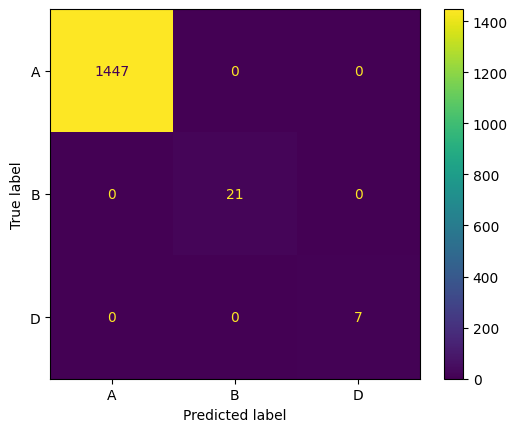

In [27]:
ConfusionMatrixDisplay.from_estimator(lgb_model, X_test, y_test);

In [28]:
lg_features = pd.DataFrame({'Feature':lgb_model.feature_names_in_, 'Importance': lgb_model.feature_importances_})
lg_features['Normalized importance'] = lg_features['Importance'] / lg_features['Importance'].sum()
lg_features.sort_values('Normalized importance', ascending=False)

,Feature,Importance,Normalized importance
2,MORA12,1552,0.404483
0,AP,1423,0.370863
4,ANTI,851,0.221788
3,SINMORA,8,0.002085
1,COOCDAT,3,0.000782


In [29]:
joblib.dump(grid_search.best_estimator_, models_dir / 'lightgbm_con_libranza.joblib')

['c:\\Users\\Usuario\\repos\\proyecto-riesgos\\calificacion-cartera\\models\\lightgbm_con_libranza.joblib']

# Sin libranza

In [30]:
super_total_sin_libranza = super_total[super_total['Cartera_x'] == 'Consumo sin libranza']
sin_libranza_columns = ['Activo', 'Vinculacion', 'SALPRES', 'Aportes', 'Reestr', 'CuentaAhorro', 'AhorroCDAT', 'MoraMax12',
                        'MoraMax24', 'MoraMax36', 'Z', 'Calif.modelo','Calif.arrastre','Calif.final', 'Calif.homologada']

super_total_sin_libranza = super_total_sin_libranza[sin_libranza_columns]
super_total_sin_libranza['AhorroCDAT'] = super_total_sin_libranza['AhorroCDAT'].fillna(0)
super_total_sin_libranza['CuentaAhorro'] = super_total_sin_libranza['CuentaAhorro'].fillna(0)
super_total_sin_libranza.dropna(subset=['Z'], inplace=True)
super_total_sin_libranza.rename(mapper={'Aportes': 'AP', 'Vinculacion': 'ANTI', 'AhorroCDAT': 'COOCDAT', 'MoraMax12':'MORA12', 
                                        'MoraMax36':'MORA36', 'MoraMax24':'MORA24', 'Reestr':'REEST', 'CuentaAhorro':'CUENAHO'}, 
                                        axis=1, inplace=True)
super_total_sin_libranza.head()

,Activo,ANTI,SALPRES,AP,REEST,CUENAHO,COOCDAT,MORA12,MORA24,MORA36,Z,Calif.modelo,Calif.arrastre,Calif.final,Calif.homologada
2,1,8469,0.0,10734793,4,836780.42,0.0,0,0,0,-3.725,A,A,A,A
3,1,8469,0.0,18227223,4,836780.42,0.0,5,5,5,-3.725,A,A,A,A
4,1,8469,0.0,2359003,4,836780.42,0.0,14,30,30,-3.375,A,A,A,A
5,1,7426,1.0,463407,4,82303.00,0.0,0,0,0,-3.725,A,A,A,A
6,1,7426,0.0,497136,4,82303.00,0.0,0,13,13,-3.725,A,A,A,A


In [32]:
for col in super_total_sin_libranza.select_dtypes(include=['str']).columns:
    print("--------------------")
    print(super_total_sin_libranza[col].value_counts())

--------------------
Calif.modelo
A    7163
C     617
B     616
E      73
D      64
Name: count, dtype: int64
--------------------
Calif.arrastre
A    7052
C     670
B     662
E      75
D      74
Name: count, dtype: int64
--------------------
Calif.final
A    7052
C     670
B     662
E      75
D      74
Name: count, dtype: int64
--------------------
Calif.homologada
A    7560
B     552
C     411
D      10
Name: count, dtype: int64


In [33]:
super_total_sin_libranza['Z'].value_counts().sort_index()

Z
-3.725    6456
-3.375     133
-3.195      50
-3.101     436
-2.751      45
-2.571       9
-2.539      34
-2.189      20
-2.009       1
-1.915       2
-1.565       2
-1.376     591
-0.752      77
-0.469     540
-0.190      21
 0.155      43
 0.434       2
 0.717      67
 1.341       4
Name: count, dtype: int64

## Modelado

In [34]:
vars = ['Activo', 'ANTI', 'SALPRES', 'AP', 'MORA12']

X = super_total_sin_libranza[vars]
y = super_total_sin_libranza['Calif.modelo']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21, stratify=y)

In [ ]:
le = LabelEncoder()
y_train_le = le.fit_transform(y_train)
y_test_le = le.transform(y_test)

dist = {'ccp_alpha':loguniform(1e-3, 1e2)}

grid_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=21), 
    param_distributions=dist, 
    scoring='f1_macro',
    n_iter=20
    )
    
grid_search.fit(X_train, y_train_le)

train_score = f1_score(y_train_le, grid_search.predict(X_train), average='macro')
test_score = f1_score(y_test_le, grid_search.predict(X_test), average='macro')

print(f'Best score: {grid_search.best_score_:.2f} with {grid_search.best_params_}')
print(f'Train score: {train_score:.2f}')
print(f'Test score: {test_score:.2f}')

Best score: 0.85 with {'ccp_alpha': np.float64(0.002965535330434669)}
Train score: 0.86
Test score: 0.86


In [36]:
print(classification_report(y_test_le, grid_search.best_estimator_.predict(X_test), target_names=le.classes_))

              precision    recall  f1-score   support

           A       1.00      1.00      1.00      1433
           B       0.89      0.98      0.93       123
           C       0.92      0.88      0.90       123
           D       1.00      0.31      0.47        13
           E       1.00      1.00      1.00        15

    accuracy                           0.98      1707
   macro avg       0.96      0.83      0.86      1707
weighted avg       0.98      0.98      0.98      1707



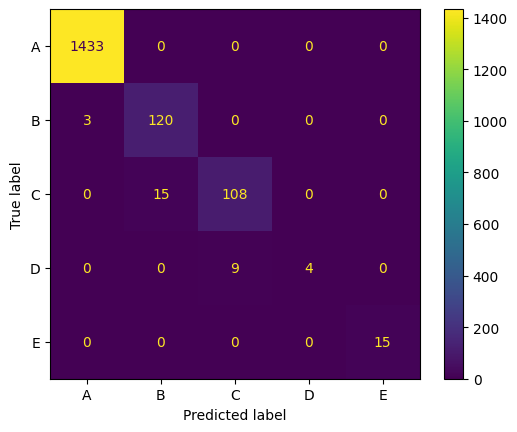

In [37]:
ConfusionMatrixDisplay.from_estimator(grid_search.best_estimator_, X_test, y_test_le, display_labels=le.classes_);

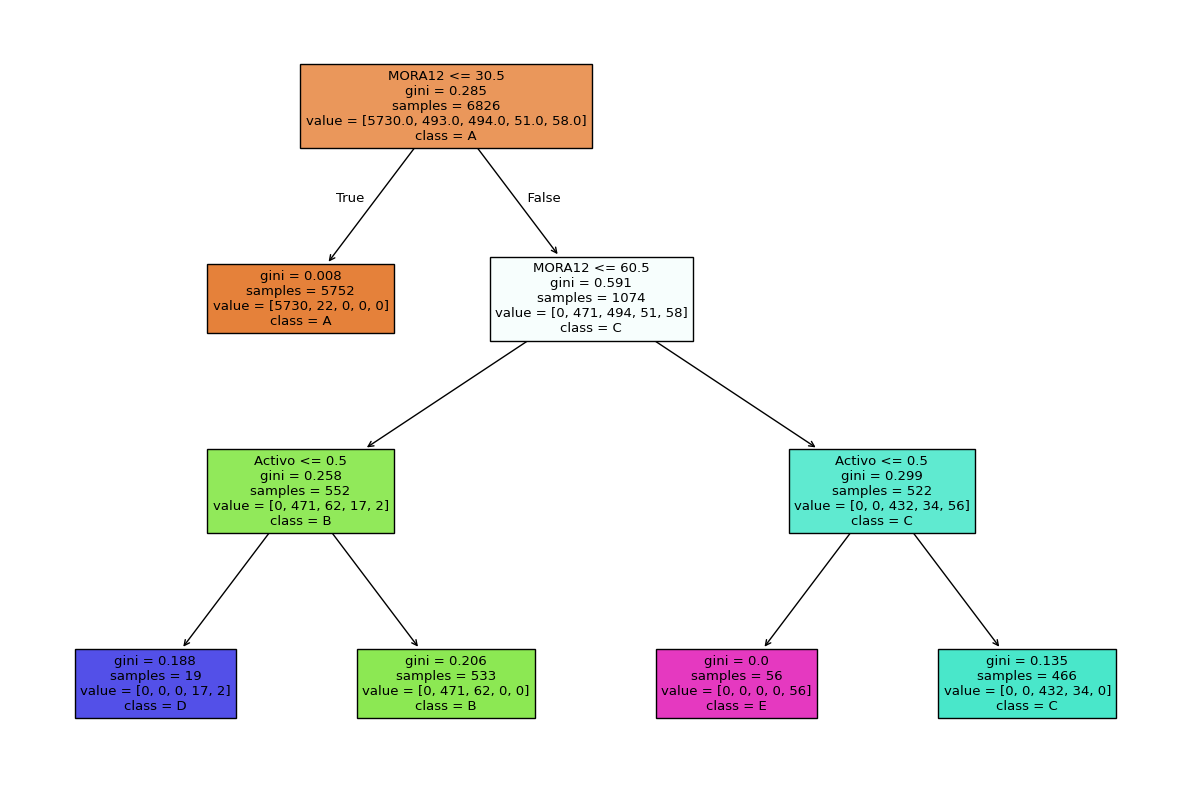

In [38]:
plt.figure(figsize=(15,10))
plot_tree(grid_search.best_estimator_, filled=True, feature_names=X.columns, class_names=le.classes_)
plt.show();

In [39]:
joblib.dump(grid_search.best_estimator_, models_dir / 'decision_tree_sin_libranza.joblib')

['c:\\Users\\Usuario\\repos\\proyecto-riesgos\\calificacion-cartera\\models\\decision_tree_sin_libranza.joblib']

In [40]:
lgb_model = LGBMClassifier(
    objective='multiclass', # Objetivo de clasificación multiclase
    class_weight='balanced', # Hace balanceo de clases
    verbose=0,
    )

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],  # Conjunto de validación
    eval_metric='logloss',  # 'auc', 'error', etc.
    callbacks=[lgb.early_stopping(stopping_rounds=20)],  # Detiene si no mejora en 20 rondas
    )

print(f'La exactitud de este modelo con los datos de entrenamiento es: {lgb_model.score(X_train, y_train):.3f}')
print(f'La exactitud de este modelo con los datos de prueba es: {lgb_model.score(X_test, y_test):.3f}')

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[52]	valid_0's multi_logloss: 0.0516583
La exactitud de este modelo con los datos de entrenamiento es: 0.999
La exactitud de este modelo con los datos de prueba es: 0.982


In [41]:
lgb_model.get_params()

{'boosting_type': 'gbdt',
 'class_weight': 'balanced',
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.1,
 'max_depth': -1,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'num_leaves': 31,
 'objective': 'multiclass',
 'random_state': None,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0,
 'verbose': 0}

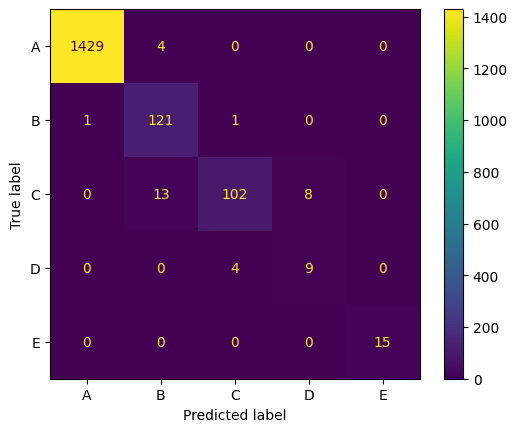

In [42]:
ConfusionMatrixDisplay.from_estimator(lgb_model, X_test, y_test);

In [43]:
print(classification_report(y_test, lgb_model.predict(X_test)))

              precision    recall  f1-score   support

           A       1.00      1.00      1.00      1433
           B       0.88      0.98      0.93       123
           C       0.95      0.83      0.89       123
           D       0.53      0.69      0.60        13
           E       1.00      1.00      1.00        15

    accuracy                           0.98      1707
   macro avg       0.87      0.90      0.88      1707
weighted avg       0.98      0.98      0.98      1707



In [44]:
lg_features = pd.DataFrame({'Feature':lgb_model.feature_names_in_, 'Importance': lgb_model.feature_importances_})
lg_features['Normalized importance'] = lg_features['Importance'] / lg_features['Importance'].sum()
lg_features.sort_values('Normalized importance', ascending=False)

,Feature,Importance,Normalized importance
4,MORA12,2866,0.370811
1,ANTI,2369,0.306508
3,AP,2211,0.286065
0,Activo,233,0.030146
2,SALPRES,50,0.006469


In [45]:
joblib.dump(grid_search.best_estimator_, models_dir / 'lightgbm_sin_libranza.joblib')

['c:\\Users\\Usuario\\repos\\proyecto-riesgos\\calificacion-cartera\\models\\lightgbm_sin_libranza.joblib']